# Clase 7 — Machine Learning Aplicado: Casos Reales

En esta clase vamos a trabajar con **tres casos prácticos** que muestran aplicaciones reales de ML:

| Caso | Empresa | Problema | Técnica |
|------|---------|----------|---------|
| 1 | San Cristóbal Seguros | Detección de fraudes | Clasificación con SMOTE |
| 2 | Amazon Prime Video | Recomendación de películas | Similitud de contenido (TF-IDF) |
| 3 | Mazda Argentina | Segmentación de clientes | Clustering (KMeans) |

In [ ]:
!pip install opendatasets --quiet

import opendatasets as od
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

RANDOM_STATE = 42

In [ ]:
from google.colab import userdata
KAGGLE_API_TOKEN = userdata.get('KAGGLE_API_TOKEN')

od.download("https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud")
od.download("https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata")

Skipping, found downloaded files in "./creditcardfraud" (use force=True to force download)
Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: juanchoalric
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata


100%|██████████| 8.89M/8.89M [00:00<00:00, 82.5MB/s]

---
## Caso 1 — Detección de Fraudes con Tarjeta de Crédito (San Cristóbal Seguros)

**Contexto:** Una aseguradora necesita detectar transacciones fraudulentas. El desafío principal es que los fraudes son **muy poco frecuentes** (menos del 1% de las transacciones), lo que genera un dataset extremadamente desbalanceado.

**Técnica:** Usamos **SMOTE** (Synthetic Minority Over-sampling Technique) para balancear las clases y un **Random Forest** para clasificar.

In [ ]:
# Intentamos cargar el dataset de fraude con tarjeta de crédito
try:
    url_fraud = '/content/creditcardfraud/creditcard.csv'
    df_fraud = pd.read_csv(url_fraud)
    print(f"Dataset cargado desde URL: {df_fraud.shape}")
except Exception as e:
    print(f"No se pudo descargar el dataset ({e})")
    print("Generando datos sintéticos de fraude...")
    from sklearn.datasets import make_classification
    X_synth, y_synth = make_classification(
        n_samples=10000, n_features=30, n_informative=5,
        n_classes=2, weights=[0.98, 0.02],
        random_state=RANDOM_STATE
    )
    df_fraud = pd.DataFrame(X_synth, columns=[f'V{i}' for i in range(1, 31)])
    df_fraud['Class'] = y_synth
    df_fraud.insert(0, 'Time', np.arange(len(df_fraud)))
    df_fraud['Amount'] = np.abs(np.random.normal(100, 50, len(df_fraud)))
    print(f"Dataset sintético generado: {df_fraud.shape}")

df_fraud.shape

Dataset cargado desde URL: (284807, 31)


(284807, 31)

In [ ]:
df_fraud.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


No fraude: 284,315 | Fraude: 492 (0.17%)


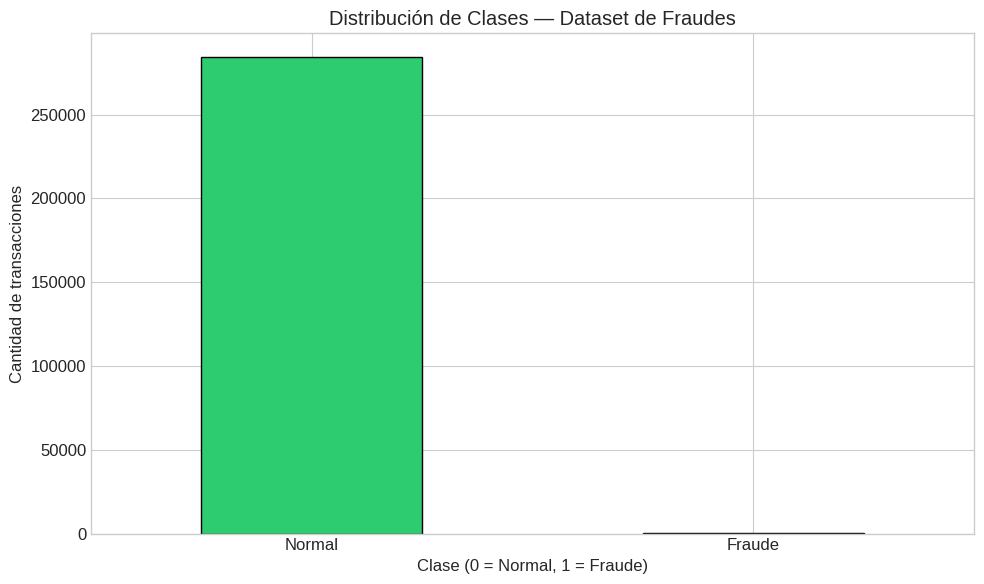

In [ ]:
# Distribución de clases
conteo = df_fraud['Class'].value_counts()
print(f"No fraude: {conteo[0]:,} | Fraude: {conteo[1]:,} ({conteo[1]/len(df_fraud)*100:.2f}%)")

fig, ax = plt.subplots()
conteo.plot(kind='bar', color=['#2ecc71', '#e74c3c'], edgecolor='black', ax=ax)
ax.set_title('Distribución de Clases — Dataset de Fraudes')
ax.set_xlabel('Clase (0 = Normal, 1 = Fraude)')
ax.set_ylabel('Cantidad de transacciones')
ax.set_xticklabels(['Normal', 'Fraude'], rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X = df_fraud.drop('Class', axis=1)
y = df_fraud['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
print(f"Fraudes en train: {y_train.sum()} | Fraudes en test: {y_test.sum()}")

Train: 199,364 | Test: 85,443
Fraudes en train: 344 | Fraudes en test: 148


In [ ]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline([
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     85295
      Fraude       0.88      0.80      0.84       148

    accuracy                           1.00     85443
   macro avg       0.94      0.90      0.92     85443
weighted avg       1.00      1.00      1.00     85443



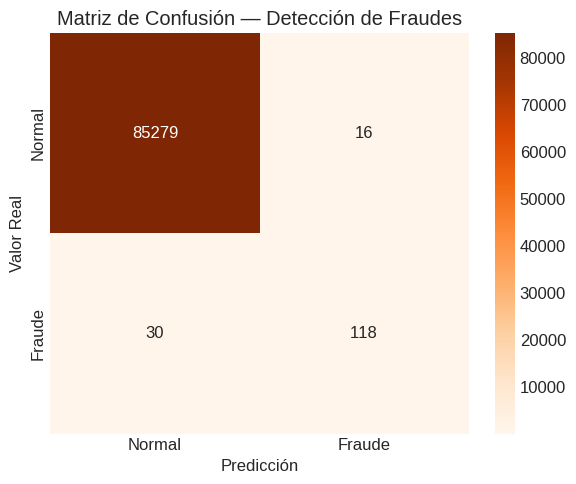

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraude']))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Normal', 'Fraude'],
            yticklabels=['Normal', 'Fraude'], ax=ax)
ax.set_title('Matriz de Confusión — Detección de Fraudes')
ax.set_xlabel('Predicción')
ax.set_ylabel('Valor Real')
plt.tight_layout()
plt.show()

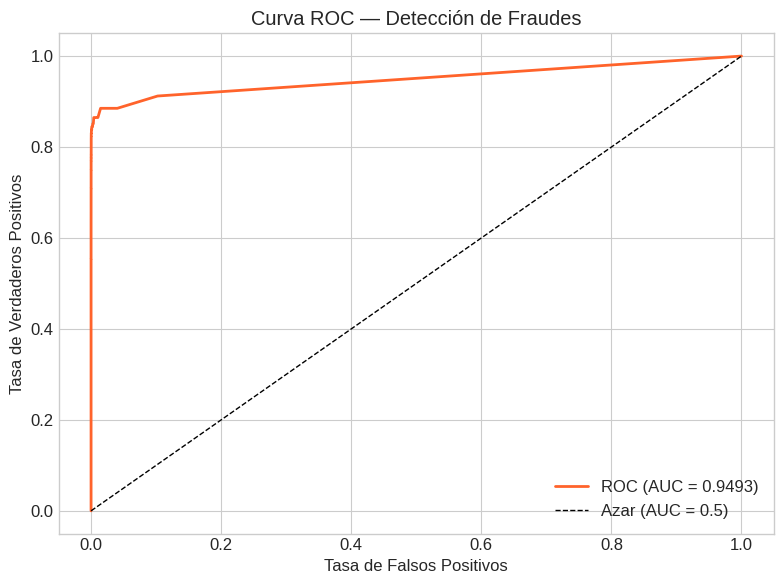

In [ ]:
y_proba = pipeline.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#FF632B', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Azar (AUC = 0.5)')
ax.set_title('Curva ROC — Detección de Fraudes')
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Conclusiones — Caso 1

- El dataset estaba **extremadamente desbalanceado** (~0.17% de fraudes).
- **SMOTE** generó ejemplos sintéticos de la clase minoritaria para equilibrar el entrenamiento.
- En fraudes, el **recall** (sensibilidad) es más importante que la precisión: preferimos detectar fraudes aunque tengamos algunos falsos positivos.
- La curva ROC nos muestra qué tan bien el modelo separa las dos clases.

---
## Caso 2 — Sistema de Recomendación de Películas (Amazon Prime Video)

**Contexto:** Un servicio de streaming quiere recomendar películas similares a las que el usuario ya vio.

**Técnica:** Usamos **TF-IDF** para vectorizar las características de cada película (géneros + palabras clave) y **similitud coseno** para encontrar las más parecidas.

In [ ]:
#

In [ ]:
import ast

# Cargamos el dataset de películas
try:
    url_movies = '/content/tmdb-movie-metadata/tmdb_5000_movies.csv'
    df_movies = pd.read_csv(url_movies)
    # Verificar que tiene las columnas esperadas
    if 'title' not in df_movies.columns or 'genres' not in df_movies.columns:
        raise ValueError("El dataset no tiene las columnas esperadas para películas")
    print(f"Dataset de películas cargado: {df_movies.shape}")
except Exception as e:
    print(f"No se pudo cargar desde URL ({e})")
    print("Creando dataset de ejemplo...")
    df_movies = pd.DataFrame({
        'title': ['Toy Story', 'Jumanji', 'The Dark Knight', 'Inception', 'Titanic',
                  'The Matrix', 'Forrest Gump', 'The Lion King', 'Finding Nemo', 'Shrek',
                  'Avatar', 'Interstellar', 'Gladiator', 'Braveheart', 'The Avengers',
                  'Iron Man', 'Spider-Man', 'Batman Begins', 'Superman', 'Wonder Woman',
                  'Frozen', 'Moana', 'Coco', 'Up', 'WALL-E',
                  'The Godfather', 'Pulp Fiction', 'Fight Club', 'The Shawshank Redemption', 'Goodfellas'],
        'genres': [
            "[{'id':16,'name':'Animation'},{'id':35,'name':'Comedy'},{'id':10751,'name':'Family'}]",
            "[{'id':12,'name':'Adventure'},{'id':14,'name':'Fantasy'},{'id':10751,'name':'Family'}]",
            "[{'id':28,'name':'Action'},{'id':80,'name':'Crime'},{'id':18,'name':'Drama'}]",
            "[{'id':28,'name':'Action'},{'id':878,'name':'Science Fiction'},{'id':12,'name':'Adventure'}]",
            "[{'id':18,'name':'Drama'},{'id':10749,'name':'Romance'}]",
            "[{'id':28,'name':'Action'},{'id':878,'name':'Science Fiction'}]",
            "[{'id':35,'name':'Comedy'},{'id':18,'name':'Drama'},{'id':10749,'name':'Romance'}]",
            "[{'id':16,'name':'Animation'},{'id':10751,'name':'Family'},{'id':18,'name':'Drama'}]",
            "[{'id':16,'name':'Animation'},{'id':10751,'name':'Family'},{'id':35,'name':'Comedy'}]",
            "[{'id':16,'name':'Animation'},{'id':35,'name':'Comedy'},{'id':14,'name':'Fantasy'}]",
            "[{'id':28,'name':'Action'},{'id':878,'name':'Science Fiction'},{'id':12,'name':'Adventure'}]",
            "[{'id':12,'name':'Adventure'},{'id':18,'name':'Drama'},{'id':878,'name':'Science Fiction'}]",
            "[{'id':28,'name':'Action'},{'id':18,'name':'Drama'},{'id':12,'name':'Adventure'}]",
            "[{'id':28,'name':'Action'},{'id':18,'name':'Drama'},{'id':36,'name':'History'}]",
            "[{'id':28,'name':'Action'},{'id':878,'name':'Science Fiction'},{'id':12,'name':'Adventure'}]",
            "[{'id':28,'name':'Action'},{'id':878,'name':'Science Fiction'},{'id':12,'name':'Adventure'}]",
            "[{'id':28,'name':'Action'},{'id':12,'name':'Adventure'},{'id':878,'name':'Science Fiction'}]",
            "[{'id':28,'name':'Action'},{'id':80,'name':'Crime'},{'id':18,'name':'Drama'}]",
            "[{'id':28,'name':'Action'},{'id':878,'name':'Science Fiction'},{'id':12,'name':'Adventure'}]",
            "[{'id':28,'name':'Action'},{'id':12,'name':'Adventure'},{'id':14,'name':'Fantasy'}]",
            "[{'id':16,'name':'Animation'},{'id':10751,'name':'Family'},{'id':35,'name':'Comedy'}]",
            "[{'id':16,'name':'Animation'},{'id':10751,'name':'Family'},{'id':35,'name':'Comedy'}]",
            "[{'id':16,'name':'Animation'},{'id':10751,'name':'Family'},{'id':18,'name':'Drama'}]",
            "[{'id':16,'name':'Animation'},{'id':35,'name':'Comedy'},{'id':12,'name':'Adventure'}]",
            "[{'id':16,'name':'Animation'},{'id':878,'name':'Science Fiction'},{'id':10751,'name':'Family'}]",
            "[{'id':18,'name':'Drama'},{'id':80,'name':'Crime'}]",
            "[{'id':18,'name':'Drama'},{'id':80,'name':'Crime'},{'id':53,'name':'Thriller'}]",
            "[{'id':18,'name':'Drama'}]",
            "[{'id':18,'name':'Drama'},{'id':80,'name':'Crime'}]",
            "[{'id':18,'name':'Drama'},{'id':80,'name':'Crime'}]"
        ],
        'keywords': [
            "[{'id':1,'name':'toy'},{'id':2,'name':'animation'},{'id':3,'name':'friendship'}]",
            "[{'id':4,'name':'board game'},{'id':5,'name':'jungle'},{'id':6,'name':'adventure'}]",
            "[{'id':7,'name':'superhero'},{'id':8,'name':'villain'},{'id':9,'name':'dark'}]",
            "[{'id':10,'name':'dream'},{'id':11,'name':'mind'},{'id':12,'name':'heist'}]",
            "[{'id':13,'name':'ship'},{'id':14,'name':'love'},{'id':15,'name':'disaster'}]",
            "[{'id':16,'name':'hacker'},{'id':17,'name':'simulation'},{'id':18,'name':'future'}]",
            "[{'id':19,'name':'life'},{'id':20,'name':'history'},{'id':21,'name':'love story'}]",
            "[{'id':22,'name':'lion'},{'id':23,'name':'africa'},{'id':24,'name':'kingdom'}]",
            "[{'id':25,'name':'fish'},{'id':26,'name':'ocean'},{'id':27,'name':'friendship'}]",
            "[{'id':28,'name':'ogre'},{'id':29,'name':'fairy tale'},{'id':30,'name':'comedy'}]",
            "[{'id':31,'name':'alien'},{'id':32,'name':'planet'},{'id':33,'name':'future'}]",
            "[{'id':34,'name':'space'},{'id':35,'name':'time'},{'id':36,'name':'love'}]",
            "[{'id':37,'name':'rome'},{'id':38,'name':'warrior'},{'id':39,'name':'revenge'}]",
            "[{'id':40,'name':'scotland'},{'id':41,'name':'war'},{'id':42,'name':'freedom'}]",
            "[{'id':43,'name':'superhero'},{'id':44,'name':'team'},{'id':45,'name':'alien'}]",
            "[{'id':46,'name':'superhero'},{'id':47,'name':'technology'},{'id':48,'name':'armor'}]",
            "[{'id':49,'name':'superhero'},{'id':50,'name':'spider'},{'id':51,'name':'power'}]",
            "[{'id':52,'name':'superhero'},{'id':53,'name':'villain'},{'id':54,'name':'fear'}]",
            "[{'id':55,'name':'superhero'},{'id':56,'name':'alien'},{'id':57,'name':'power'}]",
            "[{'id':58,'name':'superhero'},{'id':59,'name':'warrior'},{'id':60,'name':'amazon'}]",
            "[{'id':61,'name':'princess'},{'id':62,'name':'snow'},{'id':63,'name':'magic'}]",
            "[{'id':64,'name':'ocean'},{'id':65,'name':'island'},{'id':66,'name':'adventure'}]",
            "[{'id':67,'name':'music'},{'id':68,'name':'death'},{'id':69,'name':'family'}]",
            "[{'id':70,'name':'adventure'},{'id':71,'name':'old man'},{'id':72,'name':'balloon'}]",
            "[{'id':73,'name':'robot'},{'id':74,'name':'earth'},{'id':75,'name':'love'}]",
            "[{'id':76,'name':'mafia'},{'id':77,'name':'family'},{'id':78,'name':'power'}]",
            "[{'id':79,'name':'crime'},{'id':80,'name':'dark comedy'},{'id':81,'name':'violence'}]",
            "[{'id':82,'name':'identity'},{'id':83,'name':'chaos'},{'id':84,'name':'underground'}]",
            "[{'id':85,'name':'prison'},{'id':86,'name':'hope'},{'id':87,'name':'friendship'}]",
            "[{'id':88,'name':'mafia'},{'id':89,'name':'crime'},{'id':90,'name':'rise'}]"
        ]
    })
    print(f"Dataset de ejemplo creado: {df_movies.shape}")

df_movies.head()

Dataset de películas cargado: (4803, 20)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [ ]:
df_movies[['title', 'genres', 'keywords']].head(3)

,title,genres,keywords
0,Avatar,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":..."
1,Pirates of the Caribbean: At World's End,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na..."
2,Spectre,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name..."


In [ ]:
def extraer_nombres(texto):
    """Convierte '[{"id": 1, "name": "Acción"}]' en 'Acción'"""
    try:
        lista = ast.literal_eval(texto)
        return ' '.join([item['name'] for item in lista])
    except (ValueError, SyntaxError):
        return ''

df_movies['genres_clean'] = df_movies['genres'].apply(extraer_nombres)
df_movies['keywords_clean'] = df_movies['keywords'].apply(extraer_nombres)

df_movies['combined_features'] = df_movies['genres_clean'] + ' ' + df_movies['keywords_clean']
df_movies[['title', 'combined_features']].head()

,title,combined_features
0,Avatar,Action Adventure Fantasy Science Fiction cultu...
1,Pirates of the Caribbean: At World's End,Adventure Fantasy Action ocean drug abuse exot...
2,Spectre,Action Adventure Crime spy based on novel secr...
3,The Dark Knight Rises,Action Crime Drama Thriller dc comics crime fi...
4,John Carter,Action Adventure Science Fiction based on nove...


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df_movies['combined_features'])

similitud = cosine_similarity(tfidf_matrix, tfidf_matrix)
print(f"Matriz de similitud: {similitud.shape}")

Matriz de similitud: (4803, 4803)


In [ ]:
def recomendar(titulo, n=5):
    """Recomienda n películas similares a la indicada."""
    # Buscar el índice de la película
    matches = df_movies[df_movies['title'].str.contains(titulo, case=False, na=False)]
    if matches.empty:
        print(f"No se encontró '{titulo}' en el dataset.")
        return None

    idx = matches.index[0]
    scores = list(enumerate(similitud[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:n+1]

    movie_indices = [i for i, _ in scores]
    resultado = df_movies.iloc[movie_indices][['title', 'genres_clean']].copy()
    resultado['similitud'] = [s for _, s in scores]
    return resultado

In [ ]:
print("Recomendaciones para 'Toy Story':\n")
resultado = recomendar('Toy Story')
resultado

Recomendaciones para 'Toy Story':



,title,genres_clean,similitud
1541,Toy Story,Animation Comedy Family,0.514137
343,Toy Story 2,Animation Comedy Family,0.462938
903,Ted,Comedy Fantasy,0.439700
1191,Small Soldiers,Comedy Adventure Fantasy Science Fiction Action,0.439133
616,Ted 2,Comedy,0.406567


In [ ]:
print("Recomendaciones para 'Avatar':\n")
resultado = recomendar('Avatar')
resultado

Recomendaciones para 'Avatar':



,title,genres_clean,similitud
278,Planet of the Apes,Thriller Science Fiction Action Adventure,0.441154
239,Gravity,Science Fiction Thriller Drama,0.430077
2403,Aliens,Horror Action Thriller Science Fiction,0.430075
838,Alien³,Science Fiction Action Horror,0.428278
541,Soldier,Action War Science Fiction,0.425185


### Conclusiones — Caso 2

- **TF-IDF** convierte texto en vectores numéricos que capturan la importancia relativa de cada palabra.
- La **similitud coseno** mide qué tan parecidos son dos vectores (1 = idénticos, 0 = nada en común).
- Este enfoque se llama **filtrado basado en contenido**: recomienda según las características del ítem, no según otros usuarios.

---
## Caso 3 — Segmentación de Clientes con Clustering (Mazda Argentina)

**Contexto:** Una automotriz quiere segmentar su base de clientes para personalizar campañas de marketing.

**Técnica:** Usamos **KMeans** para agrupar clientes según su ingreso anual y puntaje de gasto. Evaluamos con el **método del codo** y el **coeficiente de silueta**.

In [ ]:
# Generamos datos sintéticos con 4 segmentos naturales
np.random.seed(RANDOM_STATE)

segmentos = {
    'Ahorradores':      {'ingreso': (30, 8),  'gasto': (20, 7),  'n': 125},
    'Conservadores':     {'ingreso': (70, 10), 'gasto': (25, 8),  'n': 125},
    'Jóvenes impulso':   {'ingreso': (35, 8),  'gasto': (75, 8),  'n': 125},
    'Premium':           {'ingreso': (80, 10), 'gasto': (80, 8),  'n': 125},
}

datos = []
for nombre, params in segmentos.items():
    ingreso = np.random.normal(params['ingreso'][0], params['ingreso'][1], params['n'])
    gasto = np.random.normal(params['gasto'][0], params['gasto'][1], params['n'])
    datos.append(pd.DataFrame({'ingreso_anual_k': ingreso, 'puntaje_gasto': gasto}))

df_clientes = pd.concat(datos, ignore_index=True)
df_clientes = df_clientes.clip(lower=0, upper=100)  # Limitar rangos razonables
df_clientes.describe().round(1)

,ingreso_anual_k,puntaje_gasto
count,500.0,500.0
mean,54.0,50.1
std,23.8,28.8
min,9.0,5.8
25%,31.7,22.3
50%,52.4,51.5
75%,75.2,77.6
max,100.0,100.0


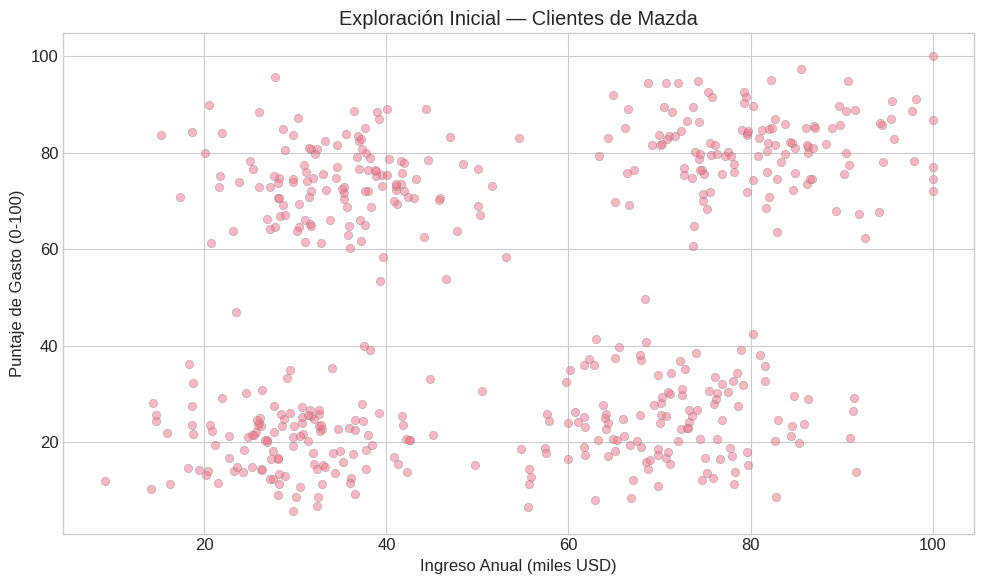

In [ ]:
fig, ax = plt.subplots()
ax.scatter(df_clientes['ingreso_anual_k'], df_clientes['puntaje_gasto'],
           alpha=0.5, edgecolors='gray', linewidths=0.5)
ax.set_title('Exploración Inicial — Clientes de Mazda')
ax.set_xlabel('Ingreso Anual (miles USD)')
ax.set_ylabel('Puntaje de Gasto (0-100)')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clientes)

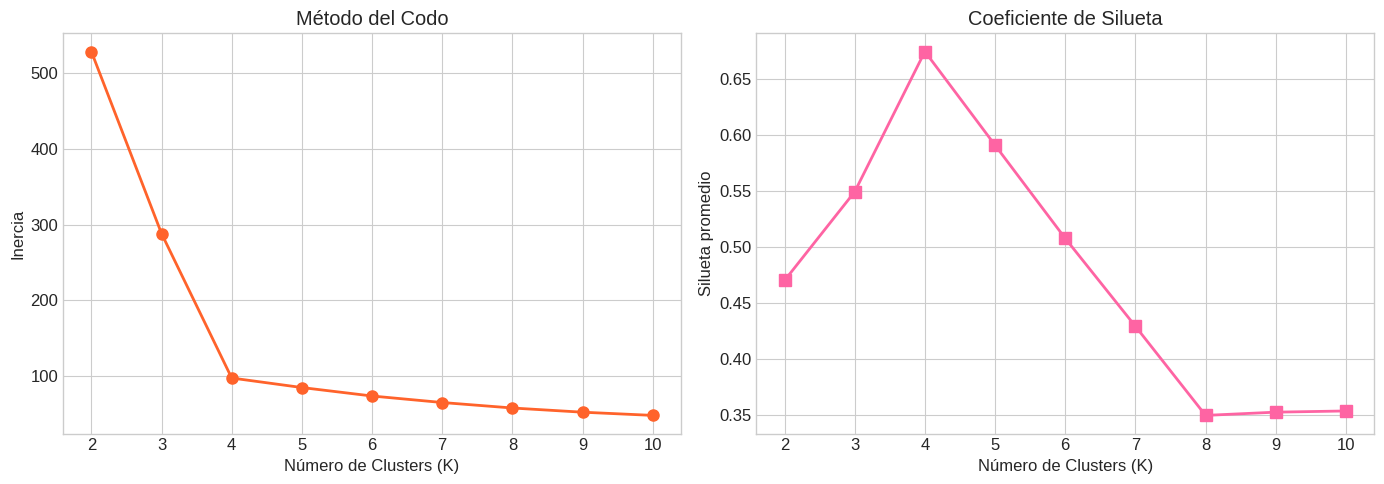

In [ ]:
K_range = range(2, 11)
inercias = []
siluetas = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inercias, 'o-', color='#FF632B', linewidth=2, markersize=8)
axes[0].set_title('Método del Codo')
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].set_ylabel('Inercia')

axes[1].plot(K_range, siluetas, 's-', color='#FE64A3', linewidth=2, markersize=8)
axes[1].set_title('Coeficiente de Silueta')
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].set_ylabel('Silueta promedio')

plt.tight_layout()
plt.show()

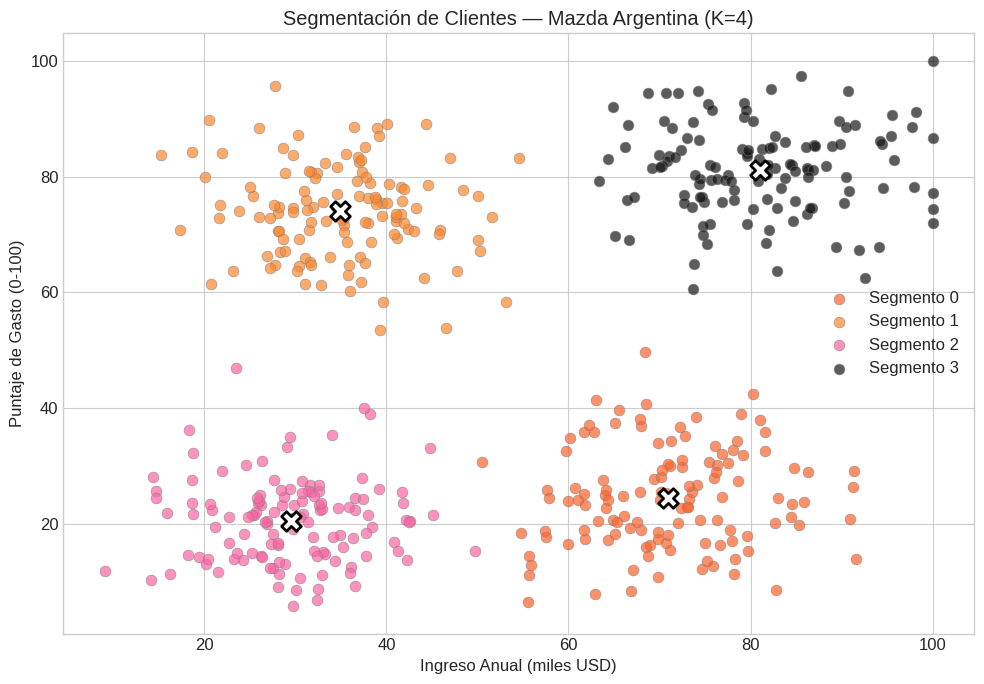

In [ ]:
# Aplicar KMeans con K=4
km_final = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)
df_clientes['segmento'] = km_final.fit_predict(X_scaled)

colores = ['#FF632B', '#FE872D', '#FE64A3', '#171717']

fig, ax = plt.subplots(figsize=(10, 7))
for i in range(4):
    mask = df_clientes['segmento'] == i
    ax.scatter(df_clientes.loc[mask, 'ingreso_anual_k'],
               df_clientes.loc[mask, 'puntaje_gasto'],
               c=colores[i], label=f'Segmento {i}',
               alpha=0.7, edgecolors='gray', linewidths=0.5, s=60)

# Centroides en coordenadas originales
centroides = scaler.inverse_transform(km_final.cluster_centers_)
ax.scatter(centroides[:, 0], centroides[:, 1],
           c='white', s=200, marker='X', edgecolors='black', linewidths=2, zorder=5)

ax.set_title('Segmentación de Clientes — Mazda Argentina (K=4)')
ax.set_xlabel('Ingreso Anual (miles USD)')
ax.set_ylabel('Puntaje de Gasto (0-100)')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Resumen por segmento
resumen = df_clientes.groupby('segmento').agg(
    cantidad=('ingreso_anual_k', 'count'),
    ingreso_promedio=('ingreso_anual_k', 'mean'),
    gasto_promedio=('puntaje_gasto', 'mean'),
    ingreso_std=('ingreso_anual_k', 'std'),
    gasto_std=('puntaje_gasto', 'std')
).round(1)

resumen

,cantidad,ingreso_promedio,gasto_promedio,ingreso_std,gasto_std
segmento,,,,,
0,124,70.9,24.6,8.6,8.6
1,125,34.9,74.0,7.8,8.0
2,126,29.5,20.6,7.5,7.2
3,125,81.0,81.2,9.1,7.8


### Conclusiones — Caso 3

- **KMeans** agrupó exitosamente a los clientes en 4 segmentos diferenciados.
- El **método del codo** y el **coeficiente de silueta** coincidieron en que K=4 es una buena elección.
- Cada segmento tiene un perfil claro que permite diseñar estrategias de marketing personalizadas.

---
## Resumen de la Clase

| Caso | Tipo de problema | Técnica clave | Métrica principal |
|------|-----------------|---------------|------------------|
| Fraudes | Clasificación binaria desbalanceada | SMOTE + Random Forest | Recall / AUC-ROC |
| Películas | Recomendación basada en contenido | TF-IDF + Similitud Coseno | Similitud (0 a 1) |
| Clientes | Aprendizaje no supervisado | KMeans | Silueta / Inercia |

**Puntos clave:**
- No todos los problemas de ML son iguales: hay que elegir la técnica adecuada según el tipo de dato y el objetivo.
- El preprocesamiento (escalar, balancear, limpiar texto) es **tan importante** como el modelo.
- Siempre hay que evaluar con métricas apropiadas al problema.

---
*Material preparado por el **Ing. Juan Cruz Alric** — Introducción a la Inteligencia Artificial*